In [1]:
using Pkg
Pkg.activate("/home/camilla/u1symmetry")
Pkg.status()

  Activating project at `~/u1symmetry`


Status `~/u1symmetry/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [13f3f980] CairoMakie v0.15.10
  [7a1cc6ca] FFTW v1.10.0
  [7073ff75] IJulia v1.34.4
  [1dea7af3] OrdinaryDiffEq v7.0.0
  [6c2fb7c5] QuantumToolbox v0.47.0
  [295af30f] Revise v3.14.3
  [90137ffa] StaticArrays v1.9.18
  [789caeaf] StochasticDiffEq v7.0.0
  [2f01184e] SparseArrays v1.12.0


In [2]:
using QuantumToolbox
using LinearAlgebra
include("enlargedspace.jl")
using .SuperEnrSpace


In [3]:
using CairoMakie

# One site case
$$\hat{H} = \omega_0 \hat{a}^\dagger\hat{a} + \frac{U}{2}\hat{a}^{\dagger 2}\hat{a}^2$$
with $\mathcal{D}[\hat{a}]$ and $\mathcal{D}[\hat{a^2}]$ 

Vectorized representation of Lindblad equation: 
$$\mathcal{L}\ket{\rho} = -i(H-\tilde{H})\ket{\rho} + \sum_i \gamma_i (\sigma_{L_i}L_i\tilde{L}_i - \frac{1}{2}L_i^\dagger L_i - \frac{1}{2}\tilde{L}_i^\dagger \tilde{L}_i)\ket{\rho}$$

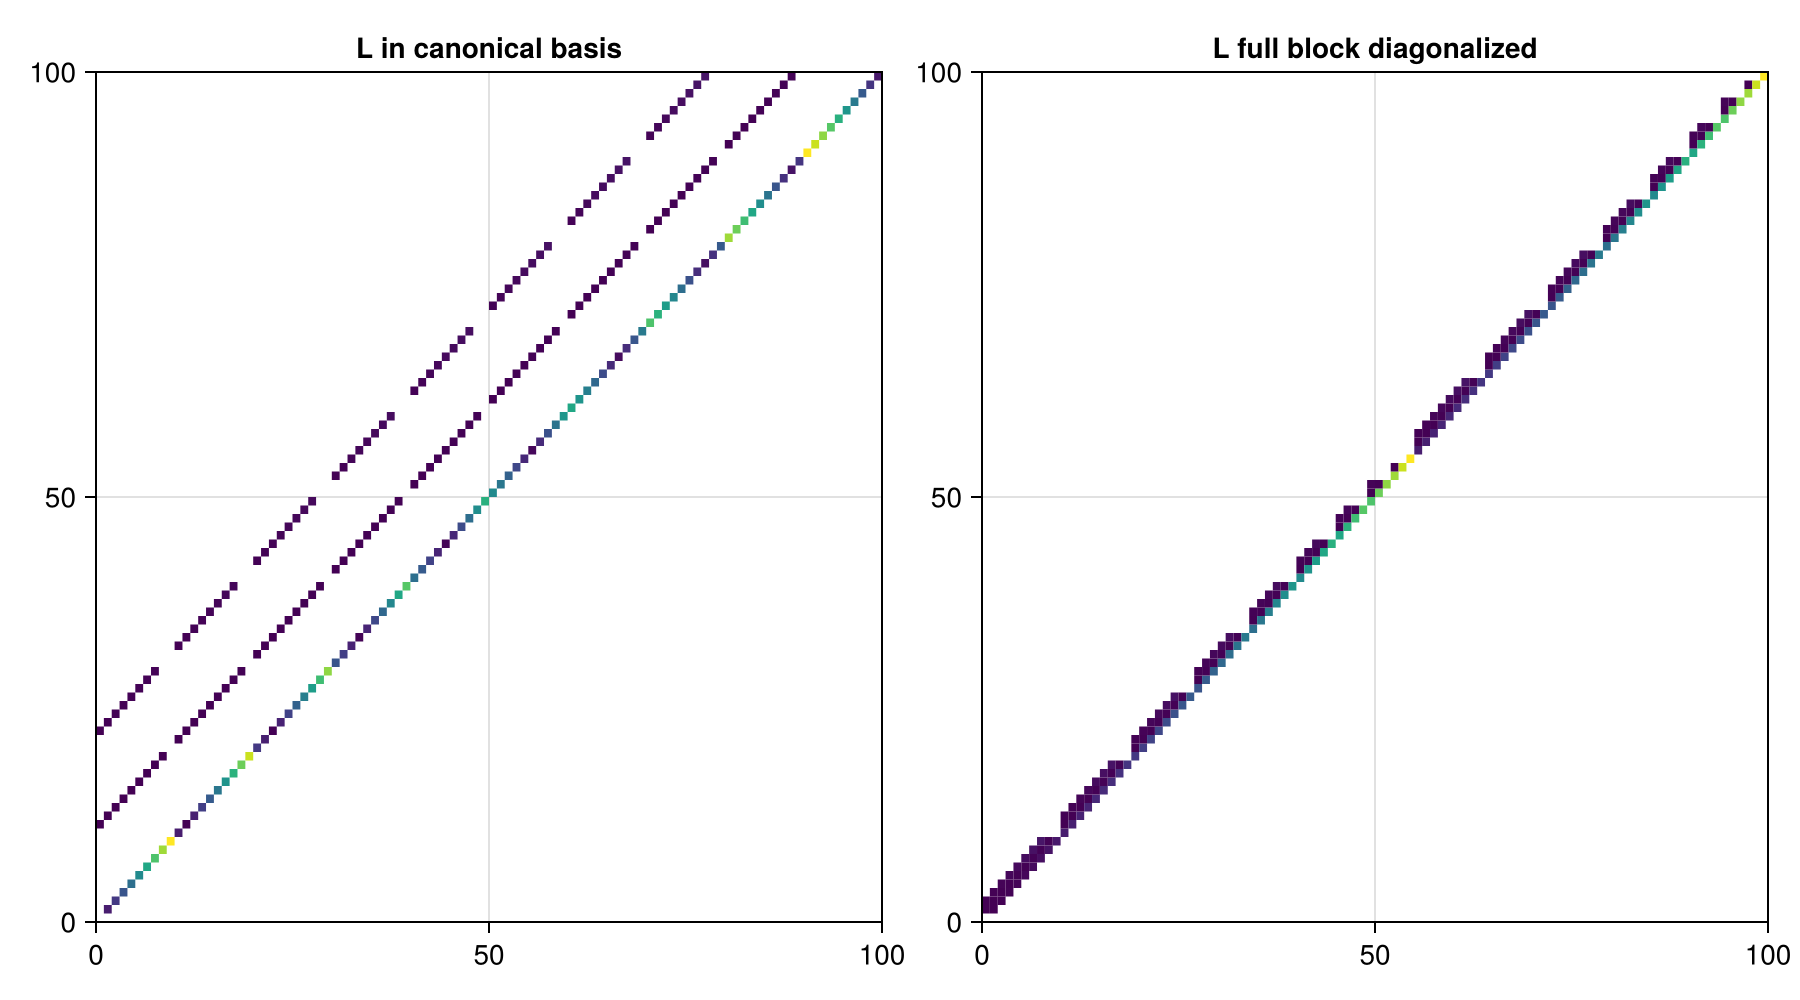

19


In [4]:
cutoff = 10
a = destroy(cutoff)
ω = 10.
U = 1.
γ = 0.1
H = ω * a' * a + U/2 * a'^2 * a^2
L = liouvillian(H, [sqrt(γ)*a, sqrt(γ)*(a^2)]);
L_diag = block_diagonal_form(L)

fig = Figure(size = (900,500))
ax1 = Axis(fig[1,1], title = "L in canonical basis")
ax2 = Axis(fig[1,2], title="L full block diagonalized")
spy!(ax1, abs.(L.data))
spy!(ax2, abs.(L_diag.B.data))
display(fig)
println(length(L_diag.blocks))




0.0
ComplexF64[]


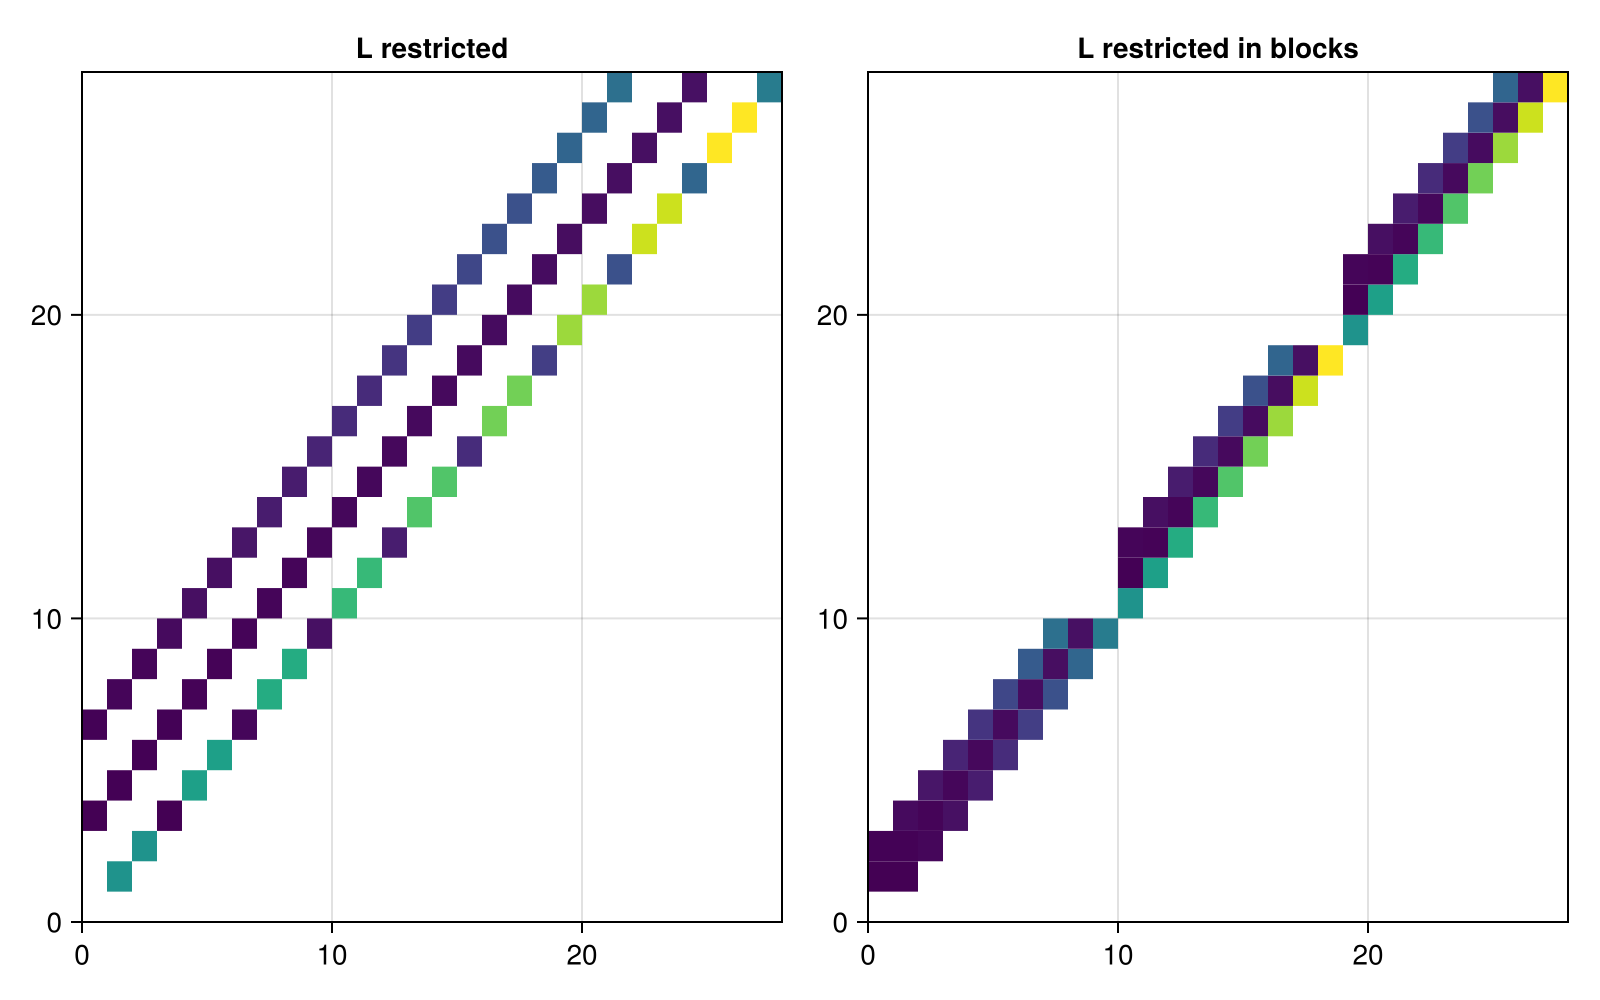

CairoMakie.Screen{IMAGE}


In [6]:
"""
case of restricted space
"""
space = s_enrspace((10,),1,2) #with dissipator D[a^2] p = 2 is necessary
vec_id = s_identity(space)
a_left, a_right = s_destroy(space, 1)
H_left = ω * a_left' * a_left + (U/2) * a_left'^2 * a_left^2
H_right = ω * a_right' * a_right + (U/2) * a_right'^2 * a_right^2

# Lindblad part: dissipator D[a] = a ρ a† - ½{a†a, ρ}
# vectorized: a_left * a_right† - ½(a†a)_left - ½(a†a)_right
#=
diss_a = a_left * a_right - 0.5 * a_left' * a_left - 0.5 * a_right' * a_right
diss_a_squared = a_left^2 * a_right^2 - 0.5 * (a_left^2)' * a_left^2 - 0.5 * (a_right^2)' * a_right^2

# total Liouvillian
L_restricted = -1im * (H_left - H_right) + γ * diss_a + γ * diss_a_squared
L_restricted_diag = block_diagonal_form(L_restricted)
=#

c_ops = [(sqrt(γ)*a_left, sqrt(γ)*a_right), (sqrt(γ)*a_left^2, sqrt(γ)*a_right^2)]
L_restricted = s_enr_liouvillian(space, H_left, H_right, c_ops)
L_restricted_diag = block_diagonal_form(L_restricted)
#identity check <I|L = 0
result = (vec_id' * L_restricted).data
nonzero_values = filter(x -> abs(x) > 1e-9, result)
println(maximum(abs, result))
println(nonzero_values)
#plotting
fig = Figure(size = (800,500))
ax = Axis(fig[1,1], title = "L restricted")
ax2 = Axis(fig[1,2], title = "L restricted in blocks")
spy!(ax, abs.(L_restricted.data))
spy!(ax2, abs.(L_restricted_diag.B.data))
display(fig)

In [7]:
evals_full = eigvals(Matrix(L.data))
evals_restricted = eigvals(Matrix(L_restricted.data))

function approx_in(val, collection; tol=1e-10)
    return any(abs(val - x) < tol for x in collection)
end

matches = [approx_in(e, evals_full) for e in evals_restricted]
println("Matched: $(sum(matches)) / $(length(evals_restricted))")
println("Unmatched eigenvalues:")
for (e, m) in zip(evals_restricted, matches)
    if !m
        println("  $e")
    end
end

# the restricted eigenvalues should be a subset of the full ones
# specifically, the ones corresponding to the |q| ≤ n_exc blocks

Matched: 28 / 28
Unmatched eigenvalues:


In [8]:
# find which eigenstates correspond to unmatched eigenvalues
evals_r, evecs_r = eigen(Matrix(L_restricted.data))

unmatched_indices = findall(i -> !approx_in(evals_r[i], evals_full), 1:length(evals_r))

println("Unmatched eigenstates analysis:")
for idx in unmatched_indices
    eval = evals_r[idx]
    evec = evecs_r[:, idx]
    
    # find dominant components
    dominant = sortperm(abs.(evec), rev=true)[1:3]
    
    println("\nEigenvalue: $eval")
    for d in dominant
        ket, bra = space.idx2state[d]
        q = sum(ket) - sum(bra)
        println("  amplitude $(round(abs(evec[d]), digits=4)) on state (ket=$ket, bra=$bra, q=$q)")
    end
end

Unmatched eigenstates analysis:


# Two site case

In this case the Hamiltonian is:
$$\hat{H} = \omega_a \hat{a}^\dagger \hat{a} + \omega_b \hat{b}^\dagger \hat{b} + \frac{U}{2}\hat{a}^{\dagger}\hat{a}^2 + \frac{U}{2}\hat{a}^{\dagger}\hat{a}^2$$
and the dissipators are $\mathcal{D}[\hat{a}]$ and $\mathcal{D}[\hat{b}]$
## Full space

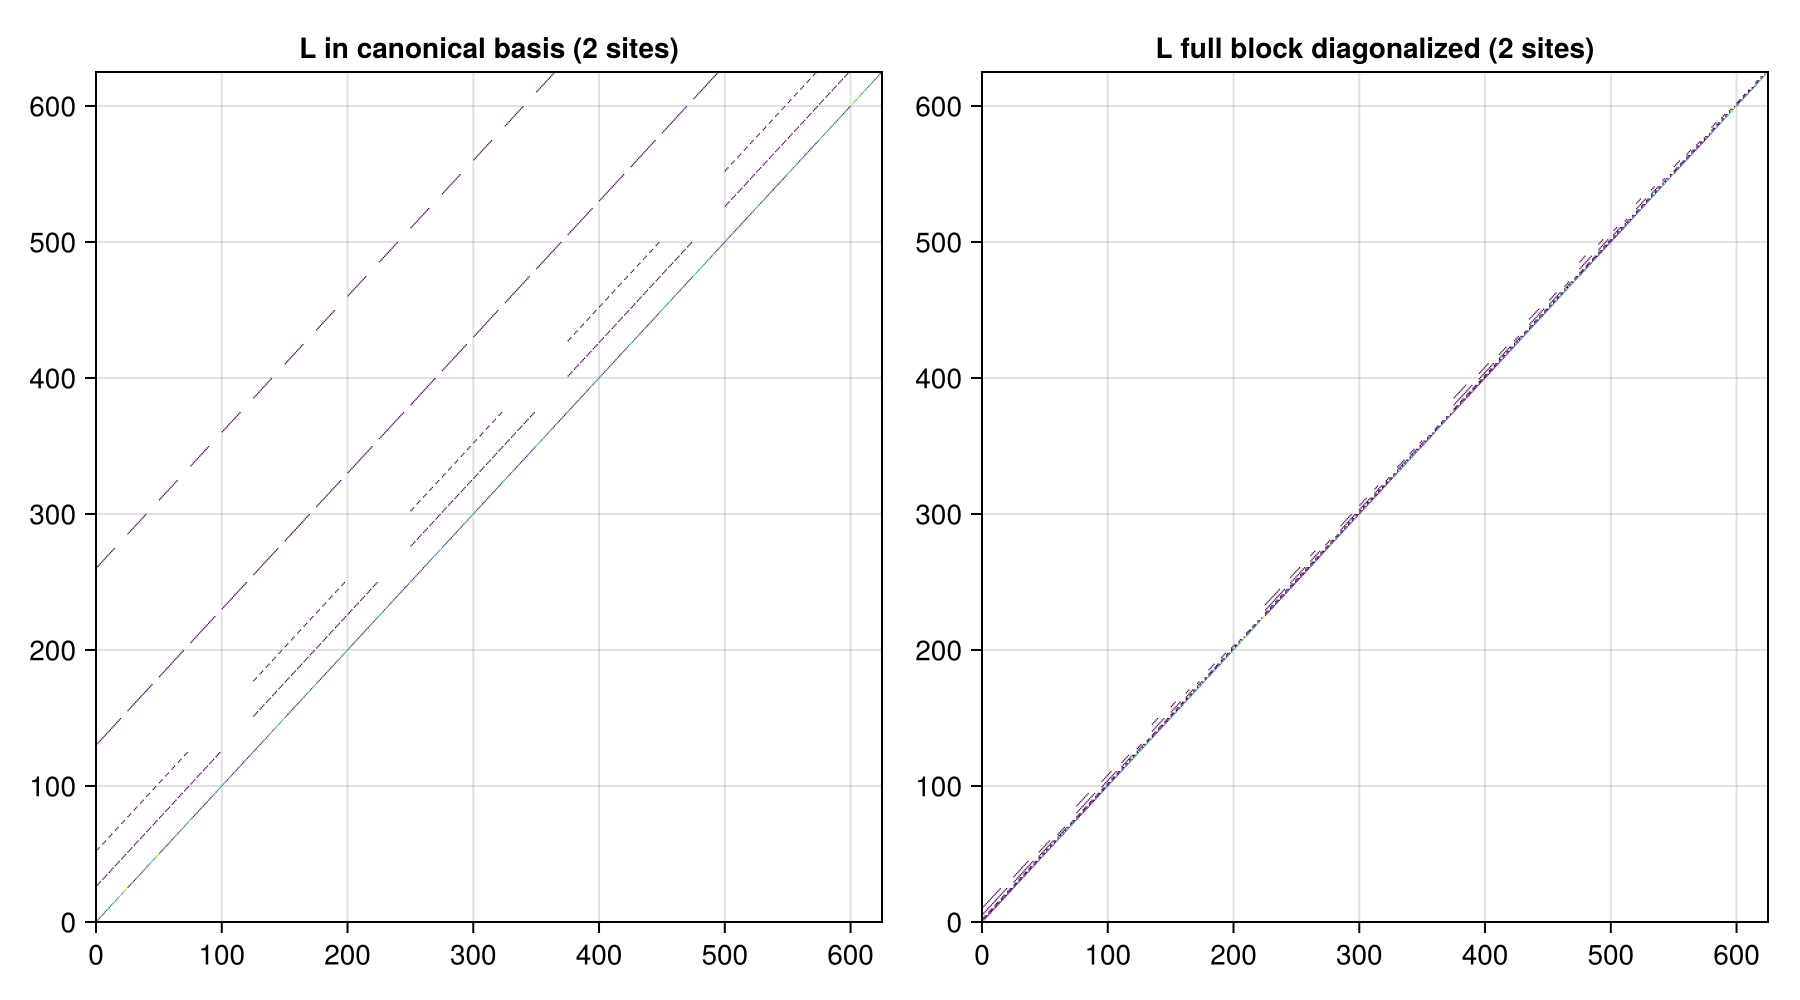

81


In [12]:
cutoff = 5
a = destroy(cutoff) ⊗ qeye(cutoff)
b = qeye(cutoff) ⊗ destroy(cutoff)
ωa = 10.
ωb = 10.
U = 1.
γa = 0.1
γb = 0.1
H = ωa * a' * a + ωb * b' * b + U/2 * a'^2 * a^2 + U/2 * b'^2 * b^2
L2 = liouvillian(H, [sqrt(γa)*a, sqrt(γb)*b, sqrt(γa)*(a^2), sqrt(γb)*(b^2)]);
L2_diag = block_diagonal_form(L2)

fig = Figure(size = (900,500))
ax1 = Axis(fig[1,1], title = "L in canonical basis (2 sites)")
ax2 = Axis(fig[1,2], title="L full block diagonalized (2 sites)")
spy!(ax1, abs.(L2.data))
spy!(ax2, abs.(L2_diag.B.data))
display(fig)
println(length(L2_diag.blocks))

## Restricted space

4.440892098500626e-16
ComplexF64[]


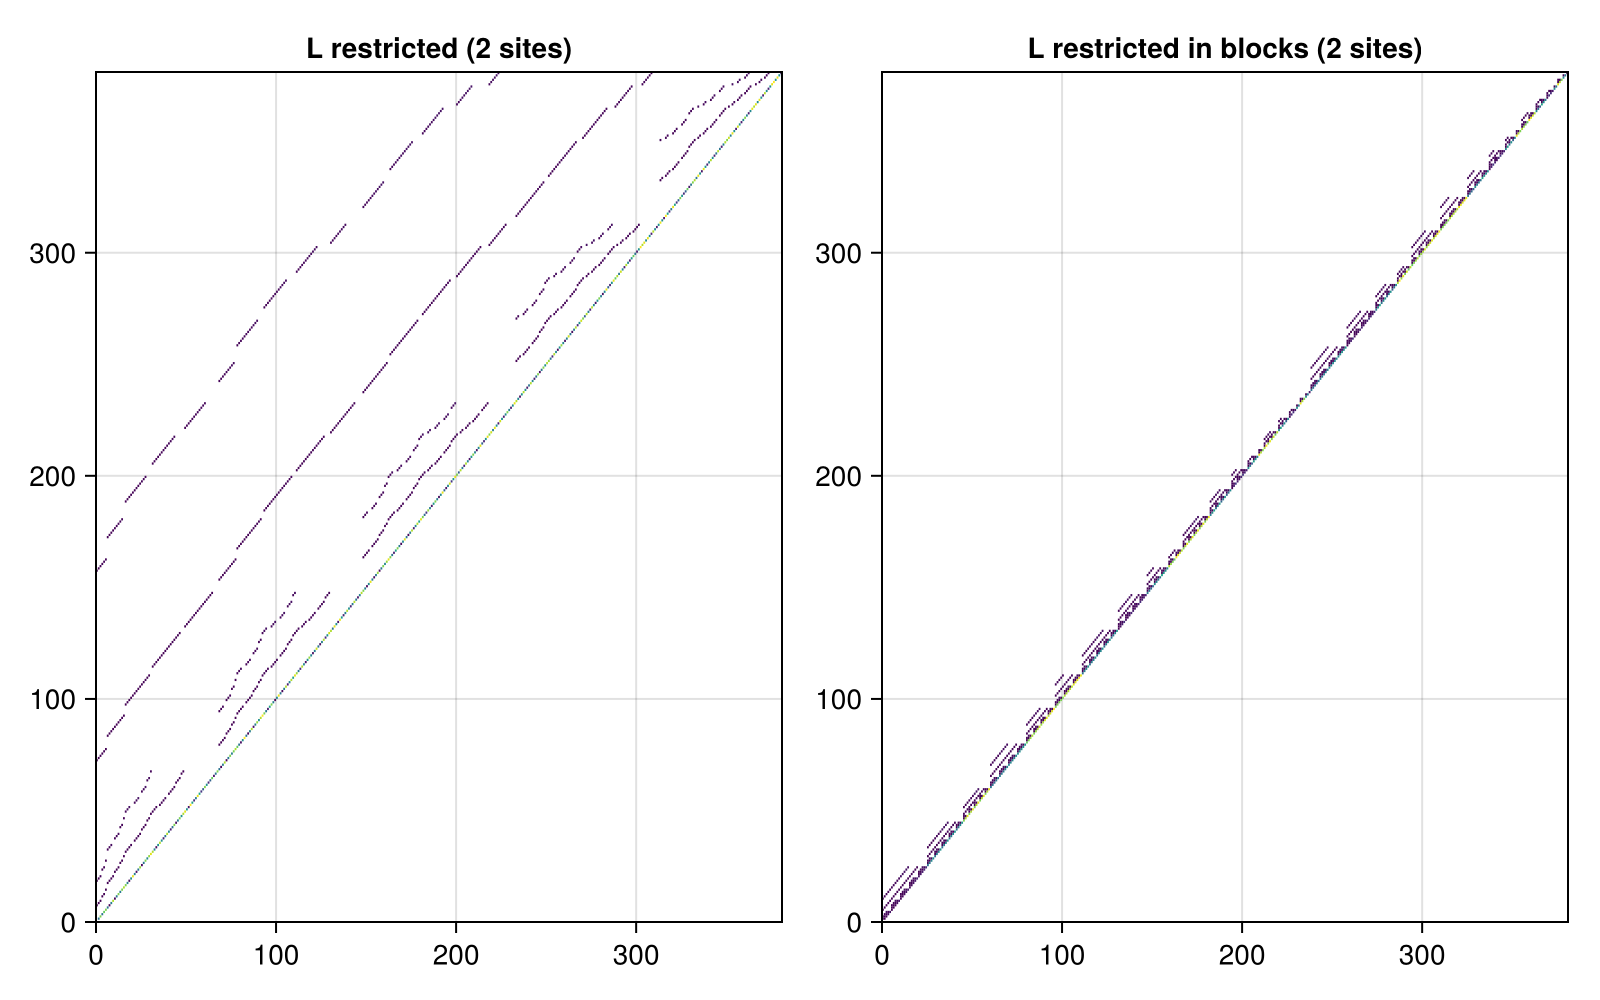

CairoMakie.Screen{IMAGE}


In [13]:
space = s_enrspace((cutoff,cutoff),2,2) 
vec_id = s_identity(space)
a_left, a_right = s_destroy(space, 1)
b_left, b_right = s_destroy(space, 2)
H_left = ωa * a_left' * a_left + ωb * b_left' * b_left + (U/2) * a_left'^2 * a_left^2 + U/2 * b_left'^2 * b_left^2
H_right = ωa * a_right' * a_right + ωb * b_right' * b_right + (U/2) * a_right'^2 * a_right^2 + U/2 * b_right'^2 * b_right^2
c_ops = [(sqrt(γa)*a_left, sqrt(γa)*a_right), (sqrt(γb)*b_left, sqrt(γb)*b_right), (sqrt(γa)*a_left^2, sqrt(γa)*a_right^2), (sqrt(γb)*b_left^2, sqrt(γb)*b_right^2)]
L2_restricted = s_enr_liouvillian(space, H_left, H_right, c_ops)
L2_restricted_diag = block_diagonal_form(L2_restricted)
#=
# Lindblad part: dissipator D[a] = a ρ a† - ½{a†a, ρ}
# vectorized: a_left * a_right - ½(a†a)_left - ½(a†a)_right
diss_a = a_left * a_right - 0.5 * a_left' * a_left - 0.5 * a_right' * a_right
diss_b = b_left * b_right - 0.5 * b_left' * b_left - 0.5 * b_right' * b_right

# total Liouvillian
L2_restricted = -1im * (H_left - H_right) + γa * diss_a + γb * diss_b
L2_restricted_diag = block_diagonal_form(L2_restricted)
=#
#identity check <I|L = 0
result = (vec_id' * L2_restricted).data
nonzero_values = filter(x -> abs(x) > 1e-9, result)
println(maximum(abs, result))
println(nonzero_values)
#plotting
fig = Figure(size = (800,500))
ax = Axis(fig[1,1], title = "L restricted (2 sites)")
ax2 = Axis(fig[1,2], title = "L restricted in blocks (2 sites)")
spy!(ax, abs.(L2_restricted.data))
spy!(ax2, abs.(L2_restricted_diag.B.data))
display(fig)

## Eigenvalues check

In [14]:
evals_full2 = eigvals(Matrix(L2.data))
evals_restricted2 = eigvals(Matrix(L2_restricted.data))

matches2 = [approx_in(e, evals_full2) for e in evals_restricted2]
println("Matched: $(sum(matches2)) / $(length(evals_restricted2))")
println("Unmatched eigenvalues:")
for (e, m) in zip(evals_restricted2, matches2)
    if !m
        println("  $e")
    end
end

Matched: 381 / 381
Unmatched eigenvalues:
